# JD+ WS Python client demo

In [1]:
from generator import generate_ts_data
from mapper import TsDataMapper
from models import Frequency, Observation, AggregationType, TsData, TsPeriod
from src.client import CommunicationManager
from datetime import date
import matplotlib.pyplot as plt

In [2]:
communicationManager = CommunicationManager()

## Descriptive Statistics

DescriptiveStatistics(id=, status=ResultStatus(type=0, message=''), n=160, n_missing=0, max=1352.080369281844, min=0.8320387021773928, average=480.29249943022194, std_dev=313.9741694130422, q25=201.20474211531547, q50=455.5106196437522, q75=720.4991064683398)


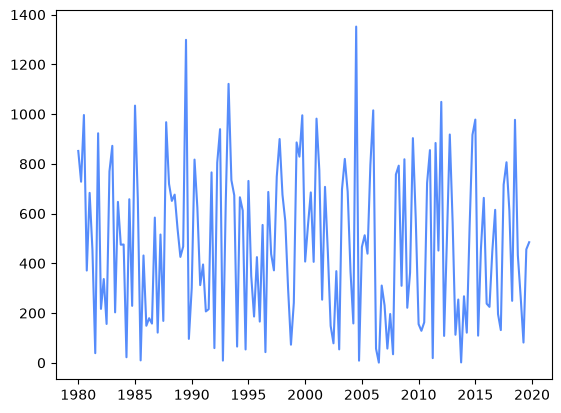

In [3]:
data_descriptive = generate_ts_data(1980, 0, Frequency.QUARTERLY, 160, True)
plt.plot(*zip(*sorted(data_descriptive.get_date_values().items())), label="Original")

descriptive_statistics = communicationManager.get_descriptive_statistics(data_descriptive)
print(descriptive_statistics)

## Temporal Disaggregation

In [4]:
# Create series that will be disaggregated
y = TsData(start=TsPeriod(year=1977, position=0, frequency=Frequency.YEARLY),
           values=(500.0,510.0,525.0,520.0))

# Call engine
disaggregated = communicationManager.process_temporal_disaggregation(y, False, False, "Rw", 12, False, 0, False, 0, False, "SqrtDiffuse", False, 0, 6)

Display disaggregation results

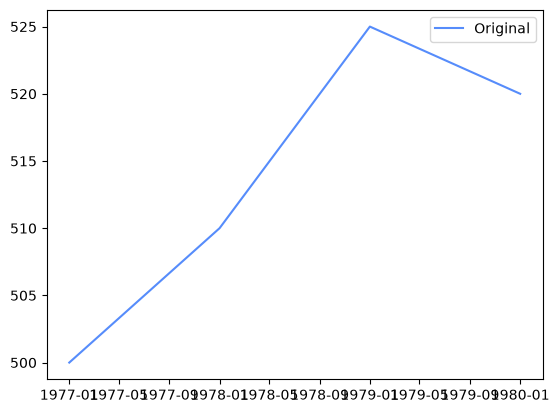

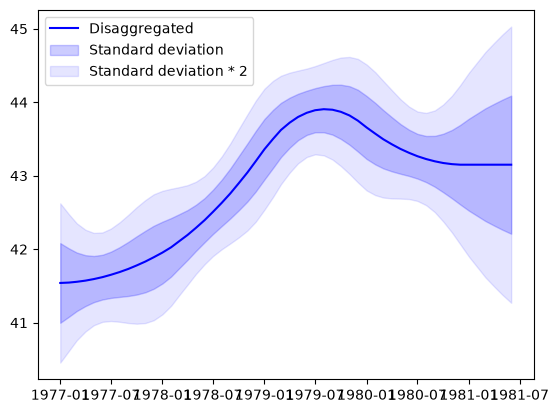

In [5]:
df = disaggregated.as_dataframe()

plt.plot(*zip(*sorted(y.get_date_values().items())), label="Original")
plt.legend()
plt.show()

plt.plot(df.index,df["disaggregated"], color="blue", label="Disaggregated")
plt.fill_between(df.index,df["disaggregated"] - df["stDevDisaggregated"],df["disaggregated"] + df["stDevDisaggregated"], color="blue", alpha=0.2, label="Standard deviation")
plt.fill_between(df.index,df["disaggregated"] - 2 * df["stDevDisaggregated"],df["disaggregated"] + 2 * df["stDevDisaggregated"], color="blue", alpha=0.1, label="Standard deviation * 2")
plt.legend()
plt.show()